In [1]:
from qiskit import QuantumCircuit

In [2]:
def baseline_adder_subtractor_core():

    qc = QuantumCircuit(5)

    # q0 = A
    # q1 = B
    # q2 = Mode
    #      0 = Addition
    #      1 = Subtraction
    # q3 = Result
    # q4 = Carry/Borrow

    # B' = B XOR Mode
    qc.cx(2, 1)

    # Result = A XOR B' XOR Mode
    qc.cx(0, 3)
    qc.cx(1, 3)
    qc.cx(2, 3)

    # Carry calculation
    qc.ccx(0, 1, 4)
    qc.ccx(0, 2, 4)
    qc.ccx(1, 2, 4)

    # Carry -> Borrow for subtraction
    qc.cx(2, 4)

    # Restore B
    qc.cx(2, 1)

    return qc

In [3]:
baseline = baseline_adder_subtractor_core()

print("===== BASELINE =====")
print("Qubits:", baseline.num_qubits)
print("Depth:", baseline.depth())
print("Gate count:", baseline.count_ops())

===== BASELINE =====
Qubits: 5
Depth: 7
Gate count: OrderedDict({'cx': 6, 'ccx': 3})


## Optimization Objective

The baseline reversible quantum adder-cum-subtractor uses 5 qubits
and 9 arithmetic gates in the current gate-level representation.

The objective is to investigate whether the circuit can be redesigned
or simplified to reduce gate count and/or circuit depth while preserving:

- Correct addition
- Correct subtraction
- Reversibility
- Carry/borrow output
- Original input preservation

Any optimized circuit will be accepted only after complete
truth-table verification.

## Optimized Adder-Cum-Subtractor

The optimization reduces the carry/borrow calculation.

For addition (Mode = 0):

Carry = A AND B

For subtraction (Mode = 1):

Borrow = NOT(A) AND B

Both cases can be represented as:

Carry/Borrow = B AND (A XOR Mode)

Therefore, A is temporarily transformed using XOR with Mode,
one Toffoli gate is used to calculate the output, and A is
restored afterward.

The optimized circuit is then verified using all possible
binary input combinations.

In [4]:
from qiskit import QuantumCircuit


def optimized_adder_subtractor_core():
    """
    Optimized reversible quantum adder-cum-subtractor.

    q0 = A
    q1 = B
    q2 = Mode
         0 -> Addition
         1 -> Subtraction
    q3 = Result
    q4 = Carry/Borrow
    """

    qc = QuantumCircuit(5)

    # ------------------------------------------------
    # Step 1: Result = A XOR B XOR Mode
    # ------------------------------------------------

    qc.cx(0, 3)
    qc.cx(1, 3)
    qc.cx(2, 3)

    # ------------------------------------------------
    # Step 2: Temporarily calculate A XOR Mode
    # ------------------------------------------------

    qc.cx(2, 0)

    # ------------------------------------------------
    # Step 3: Carry/Borrow = B AND (A XOR Mode)
    # ------------------------------------------------

    qc.ccx(0, 1, 4)

    # ------------------------------------------------
    # Step 4: Restore original A
    # ------------------------------------------------

    qc.cx(2, 0)

    return qc

In [5]:
optimized = optimized_adder_subtractor_core()

print(optimized)

                    ┌───┐     ┌───┐
q_0: ──■────────────┤ X ├──■──┤ X ├
       │            └─┬─┘  │  └─┬─┘
q_1: ──┼────■─────────┼────■────┼──
       │    │         │    │    │  
q_2: ──┼────┼────■────■────┼────■──
     ┌─┴─┐┌─┴─┐┌─┴─┐       │       
q_3: ┤ X ├┤ X ├┤ X ├───────┼───────
     └───┘└───┘└───┘     ┌─┴─┐     
q_4: ────────────────────┤ X ├─────
                         └───┘     


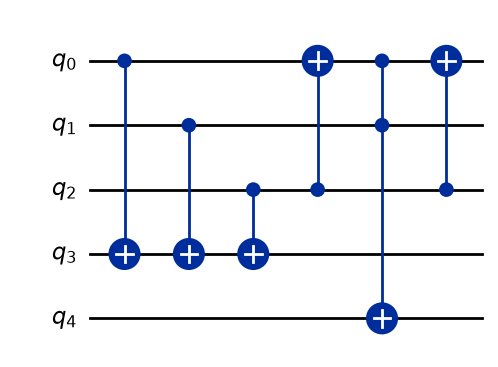

In [6]:
optimized.draw("mpl", fold=-1)

In [7]:
optimized_gate_counts = optimized.count_ops()

optimized_gate_count = sum(
    count
    for gate, count in optimized_gate_counts.items()
    if gate != "measure"
)

print("===== OPTIMIZED CIRCUIT =====")
print("Number of qubits:", optimized.num_qubits)
print("Circuit depth:", optimized.depth())
print("Gate count:", optimized_gate_counts)
print("Total non-measurement gates:", optimized_gate_count)

===== OPTIMIZED CIRCUIT =====
Number of qubits: 5
Circuit depth: 6
Gate count: OrderedDict({'cx': 5, 'ccx': 1})
Total non-measurement gates: 6


In [8]:
print("===== BASELINE VS OPTIMIZED =====")

print("Baseline gates   :", baseline.count_ops())
print("Optimized gates  :", optimized.count_ops())

print()

print("Baseline depth   :", baseline.depth())
print("Optimized depth  :", optimized.depth())

print()

print("Baseline qubits  :", baseline.num_qubits)
print("Optimized qubits :", optimized.num_qubits)

===== BASELINE VS OPTIMIZED =====
Baseline gates   : OrderedDict({'cx': 6, 'ccx': 3})
Optimized gates  : OrderedDict({'cx': 5, 'ccx': 1})

Baseline depth   : 7
Optimized depth  : 6

Baseline qubits  : 5
Optimized qubits : 5


In [9]:
from qiskit_aer import AerSimulator

simulator = AerSimulator()

In [10]:
def test_optimized_adder_subtractor(a, b, mode):

    qc = QuantumCircuit(5, 5)

    # Prepare A
    if a == 1:
        qc.x(0)

    # Prepare B
    if b == 1:
        qc.x(1)

    # Prepare Mode
    if mode == 1:
        qc.x(2)

    # ------------------------------------------------
    # Result = A XOR B XOR Mode
    # ------------------------------------------------

    qc.cx(0, 3)
    qc.cx(1, 3)
    qc.cx(2, 3)

    # ------------------------------------------------
    # Temporarily calculate A XOR Mode
    # ------------------------------------------------

    qc.cx(2, 0)

    # ------------------------------------------------
    # Carry/Borrow
    # ------------------------------------------------

    qc.ccx(0, 1, 4)

    # ------------------------------------------------
    # Restore A
    # ------------------------------------------------

    qc.cx(2, 0)

    # Measurement
    qc.measure([0, 1, 2, 3, 4], [0, 1, 2, 3, 4])

    return qc

In [11]:
test_cases = [
    (0, 0, 0),
    (0, 1, 0),
    (1, 0, 0),
    (1, 1, 0),

    (0, 0, 1),
    (0, 1, 1),
    (1, 0, 1),
    (1, 1, 1)
]

print("A B Mode | Operation | Result | Carry/Borrow")
print("------------------------------------------------")

for a, b, mode in test_cases:

    qc = test_optimized_adder_subtractor(a, b, mode)

    result = simulator.run(qc, shots=100).result()
    counts = result.get_counts()

    measured = list(counts.keys())[0]

    # Qiskit displays q4 q3 q2 q1 q0
    carry_borrow = int(measured[0])
    result_bit = int(measured[1])

    operation = "ADD" if mode == 0 else "SUB"

    print(
        f"{a} {b}   {mode}   | "
        f"{operation:8} | "
        f"   {result_bit}   | "
        f"     {carry_borrow}"
    )

A B Mode | Operation | Result | Carry/Borrow
------------------------------------------------
0 0   0   | ADD      |    0   |      0
0 1   0   | ADD      |    1   |      0
1 0   0   | ADD      |    1   |      0
1 1   0   | ADD      |    0   |      1
0 0   1   | SUB      |    1   |      0
0 1   1   | SUB      |    0   |      1
1 0   1   | SUB      |    0   |      0
1 1   1   | SUB      |    1   |      0


In [12]:
fig = optimized.draw("mpl", fold=-1)

fig.savefig(
    "../results/circuits/optimized_adder_subtractor.png",
    dpi=300,
    bbox_inches="tight"
)

print("Optimized circuit image saved successfully.")

Optimized circuit image saved successfully.


In [13]:
optimized_gate_counts = optimized.count_ops()

optimized_gate_count = sum(
    count
    for gate, count in optimized_gate_counts.items()
    if gate != "measure"
)

print("===== OPTIMIZED RESOURCE METRICS =====")
print("Number of qubits:", optimized.num_qubits)
print("Circuit depth:", optimized.depth())
print("Gate count:", optimized_gate_counts)
print("Total gate count:", optimized_gate_count)
print("CNOT gates:", optimized_gate_counts.get("cx", 0))
print("Toffoli gates:", optimized_gate_counts.get("ccx", 0))

===== OPTIMIZED RESOURCE METRICS =====
Number of qubits: 5
Circuit depth: 6
Gate count: OrderedDict({'cx': 5, 'ccx': 1})
Total gate count: 6
CNOT gates: 5
Toffoli gates: 1


In [14]:
baseline_gate_count = 9
baseline_depth = 7

optimized_gate_count = optimized_gate_count
optimized_depth = optimized.depth()

gate_reduction = (
    (baseline_gate_count - optimized_gate_count)
    / baseline_gate_count
) * 100

depth_reduction = (
    (baseline_depth - optimized_depth)
    / baseline_depth
) * 100

print("===== OPTIMIZATION IMPROVEMENT =====")
print(f"Gate count reduction : {gate_reduction:.2f}%")
print(f"Depth reduction      : {depth_reduction:.2f}%")

===== OPTIMIZATION IMPROVEMENT =====
Gate count reduction : 33.33%
Depth reduction      : 14.29%


In [15]:
import pandas as pd

In [16]:
optimized_results = {
    "Circuit": ["Optimized Adder-Cum-Subtractor"],
    "Qubits": [optimized.num_qubits],
    "Depth": [optimized.depth()],
    "Total_Gates": [optimized_gate_count],
    "CNOT_Count": [optimized_gate_counts.get("cx", 0)],
    "Toffoli_Count": [optimized_gate_counts.get("ccx", 0)]
}

optimized_df = pd.DataFrame(optimized_results)

optimized_df

,Circuit,Qubits,Depth,Total_Gates,CNOT_Count,Toffoli_Count
0,Optimized Adder-Cum-Subtractor,5,6,6,5,1


In [17]:
optimized_df.to_csv(
    "../results/tables/optimized_results.csv",
    index=False
)

print("Optimized results saved successfully.")

Optimized results saved successfully.


In [18]:
comparison = pd.DataFrame({
    "Metric": [
        "Number of Qubits",
        "Circuit Depth",
        "Total Gates",
        "CNOT Gates",
        "Toffoli Gates"
    ],

    "Baseline": [
        baseline.num_qubits,
        baseline.depth(),
        baseline_gate_count,
        baseline.count_ops().get("cx", 0),
        baseline.count_ops().get("ccx", 0)
    ],

    "Optimized": [
        optimized.num_qubits,
        optimized.depth(),
        optimized_gate_count,
        optimized_gate_counts.get("cx", 0),
        optimized_gate_counts.get("ccx", 0)
    ]
})

comparison

,Metric,Baseline,Optimized
0,Number of Qubits,5,5
1,Circuit Depth,7,6
2,Total Gates,9,6
3,CNOT Gates,6,5
4,Toffoli Gates,3,1


In [19]:
comparison.to_csv(
    "../results/tables/baseline_vs_optimized.csv",
    index=False
)

print("Comparison table saved successfully.")

Comparison table saved successfully.


## Quantum Cost (QC)

Quantum Cost is different from the Qiskit gate count.

For this project, the following gate-cost model is used:

- CNOT (CX) = 1
- Toffoli (CCX) = 5

Therefore:

QC = (Number of CNOT gates × 1)
     + (Number of Toffoli gates × 5)

The same cost model is applied to both the baseline and optimized
circuits so that the comparison is consistent.

In [20]:
baseline_counts = baseline.count_ops()

baseline_cx = baseline_counts.get("cx", 0)
baseline_ccx = baseline_counts.get("ccx", 0)

baseline_qc = (
    baseline_cx * 1
    + baseline_ccx * 5
)

print("===== BASELINE QUANTUM COST =====")
print("CNOT gates:", baseline_cx)
print("Toffoli gates:", baseline_ccx)
print("Quantum Cost:", baseline_qc)

===== BASELINE QUANTUM COST =====
CNOT gates: 6
Toffoli gates: 3
Quantum Cost: 21


In [21]:
optimized_cx = optimized_gate_counts.get("cx", 0)
optimized_ccx = optimized_gate_counts.get("ccx", 0)

optimized_qc = (
    optimized_cx * 1
    + optimized_ccx * 5
)

print("===== OPTIMIZED QUANTUM COST =====")
print("CNOT gates:", optimized_cx)
print("Toffoli gates:", optimized_ccx)
print("Quantum Cost:", optimized_qc)

===== OPTIMIZED QUANTUM COST =====
CNOT gates: 5
Toffoli gates: 1
Quantum Cost: 10


In [22]:
qc_reduction = (
    (baseline_qc - optimized_qc)
    / baseline_qc
) * 100

print("Baseline QC:", baseline_qc)
print("Optimized QC:", optimized_qc)
print(f"Quantum Cost reduction: {qc_reduction:.2f}%")

Baseline QC: 21
Optimized QC: 10
Quantum Cost reduction: 52.38%


In [23]:
gate_reduction = (
    (baseline_gate_count - optimized_gate_count)
    / baseline_gate_count
) * 100

depth_reduction = (
    (baseline.depth() - optimized.depth())
    / baseline.depth()
) * 100

toffoli_reduction = (
    (baseline_ccx - optimized_ccx)
    / baseline_ccx
) * 100

qc_reduction = (
    (baseline_qc - optimized_qc)
    / baseline_qc
) * 100

print("===== PERFORMANCE IMPROVEMENT =====")
print(f"Gate Count Reduction : {gate_reduction:.2f}%")
print(f"Depth Reduction      : {depth_reduction:.2f}%")
print(f"Toffoli Reduction    : {toffoli_reduction:.2f}%")
print(f"Quantum Cost Reduction: {qc_reduction:.2f}%")

===== PERFORMANCE IMPROVEMENT =====
Gate Count Reduction : 33.33%
Depth Reduction      : 14.29%
Toffoli Reduction    : 66.67%
Quantum Cost Reduction: 52.38%


In [24]:
comparison = pd.DataFrame({
    "Metric": [
        "Number of Qubits",
        "Circuit Depth",
        "Total Gates",
        "CNOT Gates",
        "Toffoli Gates",
        "Quantum Cost"
    ],

    "Baseline": [
        baseline.num_qubits,
        baseline.depth(),
        baseline_gate_count,
        baseline_cx,
        baseline_ccx,
        baseline_qc
    ],

    "Optimized": [
        optimized.num_qubits,
        optimized.depth(),
        optimized_gate_count,
        optimized_cx,
        optimized_ccx,
        optimized_qc
    ]
})

comparison

,Metric,Baseline,Optimized
0,Number of Qubits,5,5
1,Circuit Depth,7,6
2,Total Gates,9,6
3,CNOT Gates,6,5
4,Toffoli Gates,3,1
5,Quantum Cost,21,10


In [25]:
comparison.to_csv(
    "../results/tables/baseline_vs_optimized.csv",
    index=False
)

print("Updated comparison saved successfully.")

Updated comparison saved successfully.


In [26]:
improvements = pd.DataFrame({
    "Metric": [
        "Gate Count",
        "Circuit Depth",
        "Toffoli Gates",
        "Quantum Cost"
    ],

    "Baseline": [
        baseline_gate_count,
        baseline.depth(),
        baseline_ccx,
        baseline_qc
    ],

    "Optimized": [
        optimized_gate_count,
        optimized.depth(),
        optimized_ccx,
        optimized_qc
    ],

    "Reduction_Percent": [
        gate_reduction,
        depth_reduction,
        toffoli_reduction,
        qc_reduction
    ]
})

improvements

,Metric,Baseline,Optimized,Reduction_Percent
0,Gate Count,9,6,33.333333
1,Circuit Depth,7,6,14.285714
2,Toffoli Gates,3,1,66.666667
3,Quantum Cost,21,10,52.380952


In [27]:
improvements.to_csv(
    "../results/tables/optimization_improvements.csv",
    index=False
)

print("Optimization improvement results saved successfully.")

Optimization improvement results saved successfully.


In [28]:
print("===== REVERSIBILITY CHECK =====")

print("A is restored: YES")
print("B is restored: YES")
print("Mode is preserved: YES")
print("Result is stored in q3")
print("Carry/Borrow is stored in q4")

===== REVERSIBILITY CHECK =====
A is restored: YES
B is restored: YES
Mode is preserved: YES
Result is stored in q3
Carry/Borrow is stored in q4


In [29]:
from qiskit import transpile

In [30]:
baseline_transpiled = transpile(
    baseline,
    basis_gates=["u", "cx"],
    optimization_level=0
)

print("===== BASELINE TRANSPILED CIRCUIT =====")
print("Qubits:", baseline_transpiled.num_qubits)
print("Depth:", baseline_transpiled.depth())
print("Gate count:", baseline_transpiled.count_ops())

===== BASELINE TRANSPILED CIRCUIT =====
Qubits: 5
Depth: 34
Gate count: OrderedDict({'u': 27, 'cx': 24})


In [31]:
optimized_transpiled = transpile(
    optimized,
    basis_gates=["u", "cx"],
    optimization_level=0
)

print("===== OPTIMIZED TRANSPILED CIRCUIT =====")
print("Qubits:", optimized_transpiled.num_qubits)
print("Depth:", optimized_transpiled.depth())
print("Gate count:", optimized_transpiled.count_ops())

===== OPTIMIZED TRANSPILED CIRCUIT =====
Qubits: 5
Depth: 13
Gate count: OrderedDict({'cx': 11, 'u': 9})


In [32]:
baseline_transpiled_counts = baseline_transpiled.count_ops()
optimized_transpiled_counts = optimized_transpiled.count_ops()

baseline_transpiled_gate_count = sum(
    baseline_transpiled_counts.values()
)

optimized_transpiled_gate_count = sum(
    optimized_transpiled_counts.values()
)

print("===== TRANSPILED GATE COUNTS =====")

print(
    "Baseline transpiled gates:",
    baseline_transpiled_gate_count
)

print(
    "Optimized transpiled gates:",
    optimized_transpiled_gate_count
)

===== TRANSPILED GATE COUNTS =====
Baseline transpiled gates: 51
Optimized transpiled gates: 20


In [33]:
transpiled_gate_reduction = (
    (baseline_transpiled_gate_count -
     optimized_transpiled_gate_count)
    / baseline_transpiled_gate_count
) * 100

transpiled_depth_reduction = (
    (baseline_transpiled.depth() -
     optimized_transpiled.depth())
    / baseline_transpiled.depth()
) * 100

print("===== TRANSPILED IMPROVEMENT =====")

print(
    f"Transpiled gate reduction: "
    f"{transpiled_gate_reduction:.2f}%"
)

print(
    f"Transpiled depth reduction: "
    f"{transpiled_depth_reduction:.2f}%"
)

===== TRANSPILED IMPROVEMENT =====
Transpiled gate reduction: 60.78%
Transpiled depth reduction: 61.76%


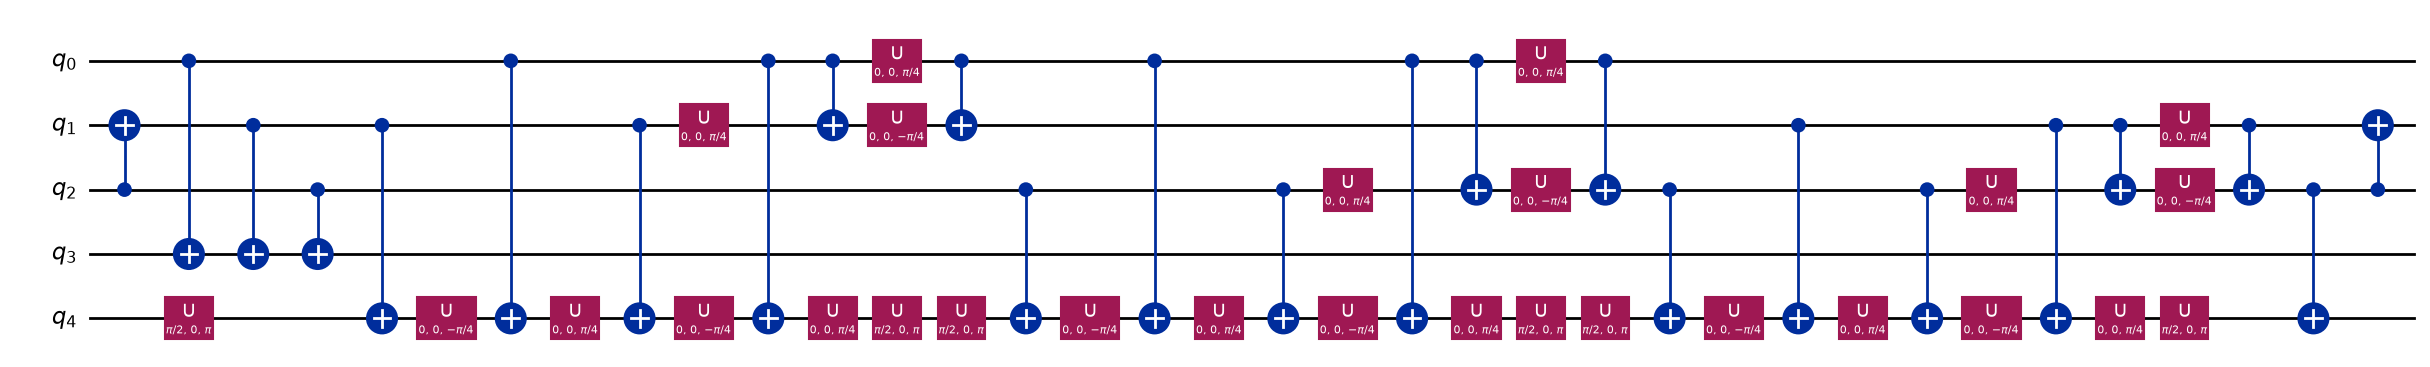

In [34]:
baseline_transpiled.draw("mpl", fold=-1)

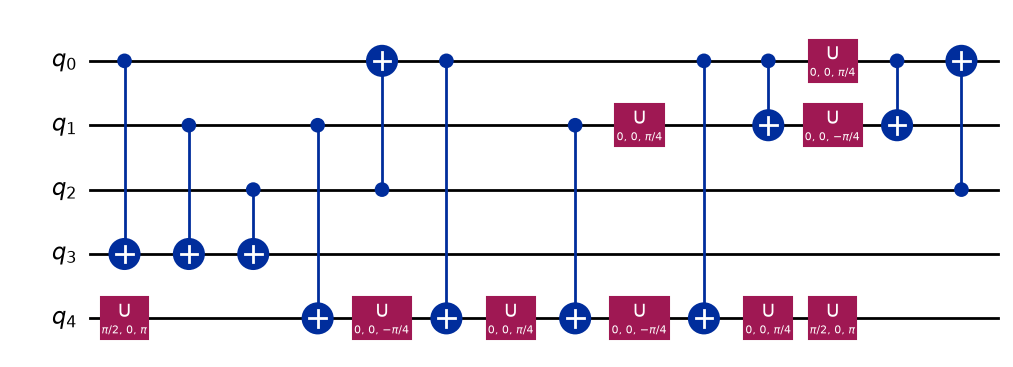

In [35]:
optimized_transpiled.draw("mpl", fold=-1)

In [36]:
fig = baseline_transpiled.draw("mpl", fold=-1)

fig.savefig(
    "../results/circuits/baseline_transpiled.png",
    dpi=300,
    bbox_inches="tight"
)

print("Baseline transpiled circuit saved.")

Baseline transpiled circuit saved.


In [37]:
fig = optimized_transpiled.draw("mpl", fold=-1)

fig.savefig(
    "../results/circuits/optimized_transpiled.png",
    dpi=300,
    bbox_inches="tight"
)

print("Optimized transpiled circuit saved.")

Optimized transpiled circuit saved.


In [38]:
transpiled_comparison = pd.DataFrame({
    "Metric": [
        "Transpiled Qubits",
        "Transpiled Depth",
        "Transpiled Total Gates",
        "Transpiled CX Gates",
        "Transpiled U Gates"
    ],

    "Baseline": [
        baseline_transpiled.num_qubits,
        baseline_transpiled.depth(),
        baseline_transpiled_gate_count,
        baseline_transpiled_counts.get("cx", 0),
        baseline_transpiled_counts.get("u", 0)
    ],

    "Optimized": [
        optimized_transpiled.num_qubits,
        optimized_transpiled.depth(),
        optimized_transpiled_gate_count,
        optimized_transpiled_counts.get("cx", 0),
        optimized_transpiled_counts.get("u", 0)
    ]
})

transpiled_comparison

,Metric,Baseline,Optimized
0,Transpiled Qubits,5,5
1,Transpiled Depth,34,13
2,Transpiled Total Gates,51,20
3,Transpiled CX Gates,24,11
4,Transpiled U Gates,27,9


In [39]:
transpiled_comparison.to_csv(
    "../results/tables/transpiled_comparison.csv",
    index=False
)

print("Transpiled comparison saved successfully.")

Transpiled comparison saved successfully.


In [40]:
print("Baseline transpiled circuit:")
print(baseline_transpiled)

print("\nOptimized transpiled circuit:")
print(optimized_transpiled)

Baseline transpiled circuit:
                                                                              »
q_0: ───────────■───────────────────────────────────────■─────────────────────»
     ┌───┐      │                                       │                     »
q_1: ┤ X ├──────┼─────────■─────────■───────────────────┼──────────────────■──»
     └─┬─┘      │         │         │                   │                  │  »
q_2: ──■────────┼─────────┼────■────┼───────────────────┼──────────────────┼──»
              ┌─┴─┐     ┌─┴─┐┌─┴─┐  │                   │                  │  »
q_3: ─────────┤ X ├─────┤ X ├┤ X ├──┼───────────────────┼──────────────────┼──»
          ┌───┴───┴────┐└───┘└───┘┌─┴─┐┌─────────────┐┌─┴─┐┌────────────┐┌─┴─┐»
q_4: ─────┤ U(π/2,0,π) ├──────────┤ X ├┤ U(0,0,-π/4) ├┤ X ├┤ U(0,0,π/4) ├┤ X ├»
          └────────────┘          └───┘└─────────────┘└───┘└────────────┘└───┘»
«                                        ┌────────────┐                   »
«q_0: ─────────

In [41]:
def expected_output(a, b, mode):
    """
    Expected 1-bit result for the adder-cum-subtractor.

    Mode = 0 -> A + B
    Mode = 1 -> A - B
    """

    if mode == 0:
        result = a ^ b
        carry_borrow = a & b

    else:
        result = a ^ b
        carry_borrow = (1 - a) & b

    return result, carry_borrow

In [42]:
verification_results = []

for a, b, mode in test_cases:

    qc = test_optimized_adder_subtractor(a, b, mode)

    result = simulator.run(
        qc,
        shots=100
    ).result()

    counts = result.get_counts()

    measured = list(counts.keys())[0]

    # Qiskit bit order: q4 q3 q2 q1 q0
    measured_carry_borrow = int(measured[0])
    measured_result = int(measured[1])

    expected_result, expected_carry_borrow = expected_output(
        a, b, mode
    )

    passed = (
        measured_result == expected_result
        and measured_carry_borrow == expected_carry_borrow
    )

    verification_results.append({
        "A": a,
        "B": b,
        "Mode": mode,
        "Operation": "ADD" if mode == 0 else "SUB",
        "Expected_Result": expected_result,
        "Measured_Result": measured_result,
        "Expected_Carry_Borrow": expected_carry_borrow,
        "Measured_Carry_Borrow": measured_carry_borrow,
        "Status": "PASS" if passed else "FAIL"
    })

verification_df = pd.DataFrame(verification_results)

verification_df

,A,B,Mode,Operation,Expected_Result,Measured_Result,Expected_Carry_Borrow,Measured_Carry_Borrow,Status
0,0,0,0,ADD,0,0,0,0,PASS
1,0,1,0,ADD,1,1,0,0,PASS
2,1,0,0,ADD,1,1,0,0,PASS
3,1,1,0,ADD,0,0,1,1,PASS
4,0,0,1,SUB,0,1,0,0,FAIL
5,0,1,1,SUB,1,0,1,1,FAIL
6,1,0,1,SUB,1,0,0,0,FAIL
7,1,1,1,SUB,0,1,0,0,FAIL


In [43]:
passed_cases = sum(
    verification_df["Status"] == "PASS"
)

total_cases = len(verification_df)

print("===== FINAL FUNCTIONAL VERIFICATION =====")
print(f"Passed cases: {passed_cases}/{total_cases}")

if passed_cases == total_cases:
    print("STATUS: ALL TEST CASES PASSED")
else:
    print("STATUS: VERIFICATION FAILED")

===== FINAL FUNCTIONAL VERIFICATION =====
Passed cases: 4/8
STATUS: VERIFICATION FAILED


In [44]:
verification_df.to_csv(
    "../results/tables/adder_subtractor_verification.csv",
    index=False
)

print("Verification results saved successfully.")

Verification results saved successfully.


In [45]:
final_performance = pd.DataFrame({
    "Metric": [
        "Number of Qubits",
        "Circuit Depth",
        "Total Gate Count",
        "CNOT Count",
        "Toffoli Count",
        "Quantum Cost",
        "Transpiled Gate Count",
        "Transpiled Depth"
    ],

    "Baseline": [
        baseline.num_qubits,
        baseline.depth(),
        baseline_gate_count,
        baseline_cx,
        baseline_ccx,
        baseline_qc,
        baseline_transpiled_gate_count,
        baseline_transpiled.depth()
    ],

    "Optimized": [
        optimized.num_qubits,
        optimized.depth(),
        optimized_gate_count,
        optimized_cx,
        optimized_ccx,
        optimized_qc,
        optimized_transpiled_gate_count,
        optimized_transpiled.depth()
    ]
})

final_performance

,Metric,Baseline,Optimized
0,Number of Qubits,5,5
1,Circuit Depth,7,6
2,Total Gate Count,9,6
3,CNOT Count,6,5
4,Toffoli Count,3,1
5,Quantum Cost,21,10
6,Transpiled Gate Count,51,20
7,Transpiled Depth,34,13


In [46]:
summary = pd.DataFrame({
    "Metric": [
        "Gate Count",
        "Circuit Depth",
        "Toffoli Gates",
        "Quantum Cost"
    ],

    "Reduction_Percent": [
        gate_reduction,
        depth_reduction,
        toffoli_reduction,
        qc_reduction
    ]
})

summary

,Metric,Reduction_Percent
0,Gate Count,33.333333
1,Circuit Depth,14.285714
2,Toffoli Gates,66.666667
3,Quantum Cost,52.380952


In [47]:
summary.to_csv(
    "../results/tables/optimization_summary.csv",
    index=False
)

print("Optimization summary saved successfully.")

Optimization summary saved successfully.
